In [2]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [3]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [4]:
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [5]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [6]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_11704\694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [7]:
x=df.iloc[:,1:]
y=df.iloc[:,0]

In [8]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

Text(0.5, 1.0, 'qq plot')

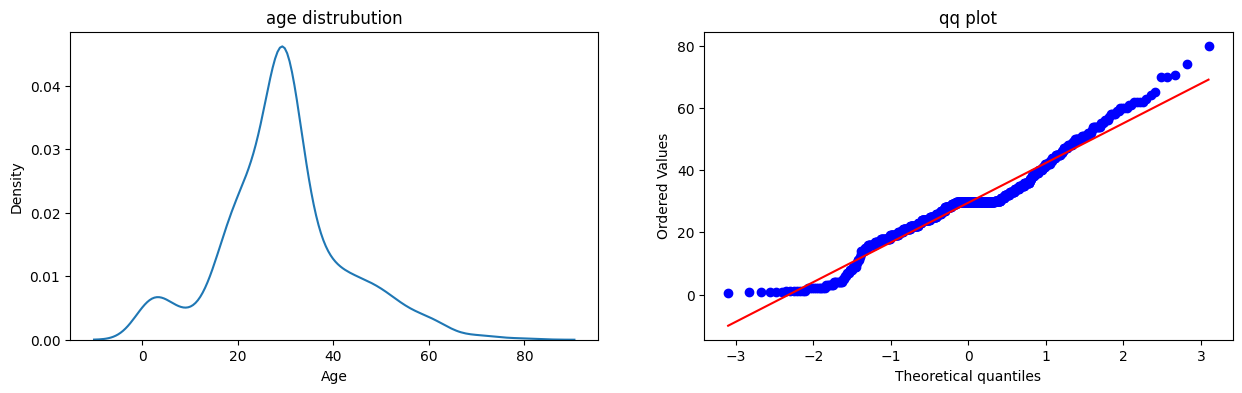

In [9]:
plt.figure(figsize=(15,4))
plt.subplot(121)
sns.kdeplot(x_train['Age'])
plt.title('age distrubution')

plt.subplot(122)
stats.probplot(x_train['Age'],dist='norm',plot=plt)
plt.title('qq plot')


Text(0.5, 1.0, 'qqplot ')

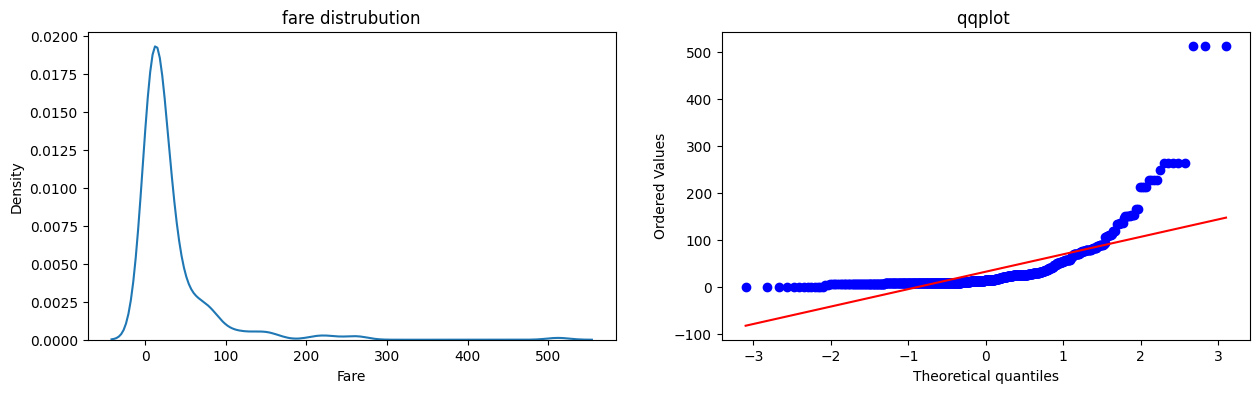

In [10]:
plt.figure(figsize=(15,4))
plt.subplot(121)
sns.kdeplot(x_train['Fare'])
plt.title('fare distrubution')
plt.subplot(122)
stats.probplot(x_train['Fare'],dist='norm',plot=plt)
plt.title('qqplot ')

In [11]:
model=LogisticRegression()
model2=DecisionTreeClassifier()

In [12]:
model.fit(x_train,y_train)
model2.fit(x_train,y_train)

y_pred=model.predict(x_test)
y_pred2=model2.predict(x_test)
print("logisticRegression::",accuracy_score(y_pred,y_test))
print("decisiontree::",accuracy_score(y_pred2,y_test))

logisticRegression:: 0.6480446927374302
decisiontree:: 0.6703910614525139


# After log transformer

In [13]:
trf=FunctionTransformer(func=np.log1p)

In [14]:
x_train_log=trf.fit_transform(x_train)
x_test_log=trf.transform(x_test)

In [15]:
model3=LogisticRegression()
model4=DecisionTreeClassifier()
model3.fit(x_train_log,y_train)
model4.fit(x_train_log,y_train)
y_pred3=model3.predict(x_test_log)
y_pred4=model4.predict(x_test_log)
print("logisticRegression::",accuracy_score(y_pred3,y_test))
print("decisiontree::",accuracy_score(y_pred4,y_test))

logisticRegression:: 0.6815642458100558
decisiontree:: 0.6983240223463687


In [16]:
#after appying log transformer the logisticregression accuracy was improve apprrox 4 and decision tree remain same log transforme only work for linear 
#model not for tree and random forest algorithum 

In [17]:
x_train_log

,Age,Fare
331,3.839452,3.384390
733,3.178054,2.639057
382,3.496508,2.188856
704,3.295837,2.180892
813,1.945910,3.474293
...,...,...
106,3.091042,2.157559
270,3.424234,3.465736
860,3.737670,2.715244
435,2.708050,4.795791


<Axes: ylabel='Density'>

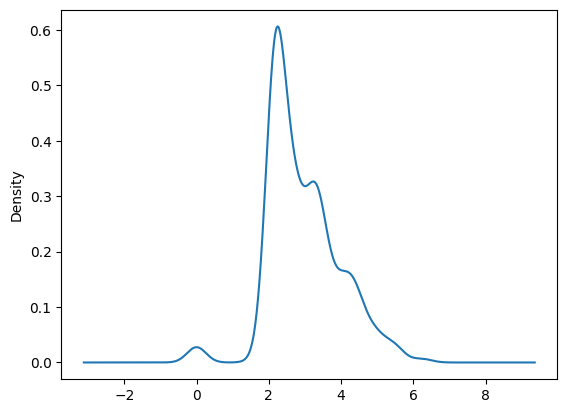

In [19]:
x_train_log['Fare'].plot(kind='kde')

<Axes: ylabel='Density'>

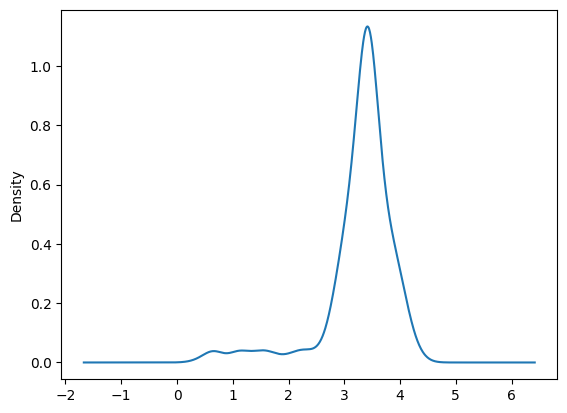

In [20]:
x_train_log['Age'].plot(kind='kde')